In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



In [2]:
df_data = pd.read_csv('datasets/opentender_clean_2022_2024.csv')

In [3]:
df_data.head()

,ocid,buyer_name,vendor_name,HPS,contract_value,procurement_method,category,item_description,date
0,ocds-20h3g7-12482010,Pemerintah Daerah Kota Surabaya,PT. DUTA BHUANA JAYA,7.445028e+08,6.666604e+08,consultancyServices,services,Jasa Konsultansi Badan Usaha Konstruksi,2024-02-02
1,ocds-20h3g7-12487010,Pemerintah Daerah Kota Surabaya,"MARGA PERKASA,CV",4.793422e+09,4.129909e+09,NaN,works,Pekerjaan Konstruksi,2024-01-15
2,ocds-20h3g7-12492010,Pemerintah Daerah Kota Surabaya,CV. Naga Kencana Wiratama,2.255991e+09,2.012700e+09,NaN,works,Pekerjaan Konstruksi,2024-01-15
3,ocds-20h3g7-12496010,Pemerintah Daerah Kota Surabaya,CV. Tiga Points Jaya Karya,3.425503e+09,2.566207e+09,NaN,works,Pekerjaan Konstruksi,2024-01-16
4,ocds-20h3g7-12504010,Pemerintah Daerah Kota Surabaya,CV. Citra Karya,1.307263e+09,1.231890e+09,NaN,works,Pekerjaan Konstruksi,2024-01-15


In [4]:
df_data.head()
df_data.info()
df_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 292852 entries, 0 to 292851
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ocid                292852 non-null  str    
 1   buyer_name          288191 non-null  str    
 2   vendor_name         164113 non-null  str    
 3   HPS                 163738 non-null  float64
 4   contract_value      164113 non-null  float64
 5   procurement_method  26328 non-null   str    
 6   category            164113 non-null  str    
 7   item_description    164113 non-null  str    
 8   date                292852 non-null  str    
dtypes: float64(2), str(7)
memory usage: 48.0 MB


,HPS,contract_value
count,1.637380e+05,1.641130e+05
mean,3.817390e+09,3.529409e+09
std,3.461689e+10,3.307242e+10
min,1.760000e+04,1.050000e+04
25%,3.795271e+08,3.504016e+08
50%,6.947567e+08,6.399824e+08
75%,1.800000e+09,1.660123e+09
max,4.286669e+12,4.242926e+12


*CLEANING NOISE*

In [5]:
df_data = df_data.drop(columns=["procurement_method"])
#kudrop noise tinggi

In [6]:
df_data = df_data.dropna(subset=[
    "vendor_name",
    "contract_value"
])

In [7]:
df_data = df_data.dropna(subset=["HPS"])

In [8]:
df_data = df_data.dropna(subset=["buyer_name"])

In [9]:
df_data = df_data[df_data["HPS"] > 0]
df_data = df_data[df_data["contract_value"] > 0]

FEATURE ENGINEERING

rasio kontrak

In [10]:
#Rasio kontrak terhadap HPS
df_data["ratio"] = df_data["contract_value"] / df_data["HPS"]

In [11]:
#B. DISCOUNT PERCENTAGE
df_data["discount_percentage"] = (
    (df_data["HPS"] - df_data["contract_value"])
    / df_data["HPS"]
) * 100

In [12]:
# C. VENDOR WIN COUNT
# Berapa kali vendor menang tender

vendor_win_count = (
    df_data.groupby("vendor_name")
    .size()
    .reset_index(name="vendor_win_count")
)
# merge ke dataframe utama
df_data = df_data.merge(
    vendor_win_count,
    on="vendor_name",
    how="left"
)


In [13]:
# D. VENDOR-INSTANSI FREQUENCY
# Seberapa sering vendor menang di instansi tertentu

vendor_instansi_frequency = (
    df_data.groupby(["vendor_name", "buyer_name"])
    .size()
    .reset_index(name="vendor_instansi_frequency")
)

# merge kembali
df_data = df_data.merge(
    vendor_instansi_frequency,
    on=["vendor_name", "buyer_name"],
    how="left"
)

In [14]:
# E. AVERAGE VENDOR RATIO
# Rata-rata ratio tiap vendor

avg_vendor_ratio = (
    df_data.groupby("vendor_name")["ratio"]
    .mean()
    .reset_index(name="avg_vendor_ratio")
)

# merge kembali
df_data = df_data.merge(
    avg_vendor_ratio,
    on="vendor_name",
    how="left"
)

In [15]:
# OPTIONAL: ROUND AGAR RAPI

df_data["ratio"] = df_data["ratio"].round(4)

df_data["discount_percentage"] = (
    df_data["discount_percentage"].round(2)
)

df_data["avg_vendor_ratio"] = (
    df_data["avg_vendor_ratio"].round(4)
)

In [16]:
# CEK HASIL FEATURE ENGINEERING

print("Feature engineering selesai.\n")

print(df_data[
    [
        "vendor_name",
        "buyer_name",
        "HPS",
        "contract_value",
        "ratio",
        "discount_percentage",
        "vendor_win_count",
        "vendor_instansi_frequency",
        "avg_vendor_ratio"
    ]
].head())

# SAVE FEATURED DATASET

df_data.to_csv(
    "featured_procurement_dataset.csv",
    index=False
)

print("\nDataset berhasil disimpan.")

Feature engineering selesai.

                  vendor_name                       buyer_name           HPS  \
0        PT. DUTA BHUANA JAYA  Pemerintah Daerah Kota Surabaya  7.445028e+08   
1            MARGA PERKASA,CV  Pemerintah Daerah Kota Surabaya  4.793422e+09   
2   CV. Naga Kencana Wiratama  Pemerintah Daerah Kota Surabaya  2.255991e+09   
3  CV. Tiga Points Jaya Karya  Pemerintah Daerah Kota Surabaya  3.425503e+09   
4             CV. Citra Karya  Pemerintah Daerah Kota Surabaya  1.307263e+09   

   contract_value   ratio  discount_percentage  vendor_win_count  \
0    6.666604e+08  0.8954                10.46                97   
1    4.129909e+09  0.8616                13.84                 2   
2    2.012700e+09  0.8922                10.78                 3   
3    2.566207e+09  0.7491                25.09                 1   
4    1.231890e+09  0.9423                 5.77                 1   

   vendor_instansi_frequency  avg_vendor_ratio  
0                          6   

In [17]:
print(df_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 161422 entries, 0 to 161421
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ocid                       161422 non-null  str    
 1   buyer_name                 161422 non-null  str    
 2   vendor_name                161422 non-null  str    
 3   HPS                        161422 non-null  float64
 4   contract_value             161422 non-null  float64
 5   category                   161422 non-null  str    
 6   item_description           161422 non-null  str    
 7   date                       161422 non-null  str    
 8   ratio                      161422 non-null  float64
 9   discount_percentage        161422 non-null  float64
 10  vendor_win_count           161422 non-null  int64  
 11  vendor_instansi_frequency  161422 non-null  int64  
 12  avg_vendor_ratio           161422 non-null  float64
dtypes: float64(5), int64(2), str(6)
memory u

**ISOLATION FOREST**

In [18]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [19]:
features = [
    "HPS",
    "contract_value",
    "ratio",
    "discount_percentage",
    "vendor_win_count",
    "vendor_instansi_frequency",
    "avg_vendor_ratio"
]

X = df_data[features]

In [20]:
X = X.dropna()

In [21]:
df_model = df_data.loc[X.index].copy()

In [22]:
df_model = df_data.loc[X.index].copy()

parameter

In [23]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [24]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

FIT MODEL

In [25]:
iso_forest.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [26]:
df_model["anomaly_label"] = iso_forest.predict(X_scaled)

In [27]:
df_model["anomaly_score"] = (
    iso_forest.decision_function(X_scaled)
)

In [28]:
top_anomalies = df_model.sort_values(
    by="anomaly_score"
).head(20)

In [29]:
print(top_anomalies[
    [
        "vendor_name",
        "buyer_name",
        "HPS",
        "contract_value",
        "ratio",
        "discount_percentage",
        "vendor_win_count",
        "anomaly_score"
    ]
])

                                     vendor_name  \
56104              PT BRANTAS ABIPRAYA (Persero)   
74555              PT BRANTAS ABIPRAYA (Persero)   
74429              PT BRANTAS ABIPRAYA (Persero)   
19847              PT BRANTAS ABIPRAYA (Persero)   
37721              PT BRANTAS ABIPRAYA (Persero)   
95543              PT BRANTAS ABIPRAYA (Persero)   
99362                          SAPTA KARYA ABADI   
74557            PT. WASKITA KARYA (PERSERO) Tbk   
95512            PT. WASKITA KARYA (PERSERO) Tbk   
38178   PT. Pembangunan Perumahan (Persero)  Tbk   
19684            PT. WASKITA KARYA (PERSERO) Tbk   
37893   PT. Pembangunan Perumahan (Persero)  Tbk   
38105              PT BRANTAS ABIPRAYA (Persero)   
117038  PT. Pembangunan Perumahan (Persero)  Tbk   
74790   PT. Pembangunan Perumahan (Persero)  Tbk   
138575  PT. Pembangunan Perumahan (Persero)  Tbk   
74831   PT. Pembangunan Perumahan (Persero)  Tbk   
74430                 PT. NINDYA KARYA (Persero)   
19821   PT. 

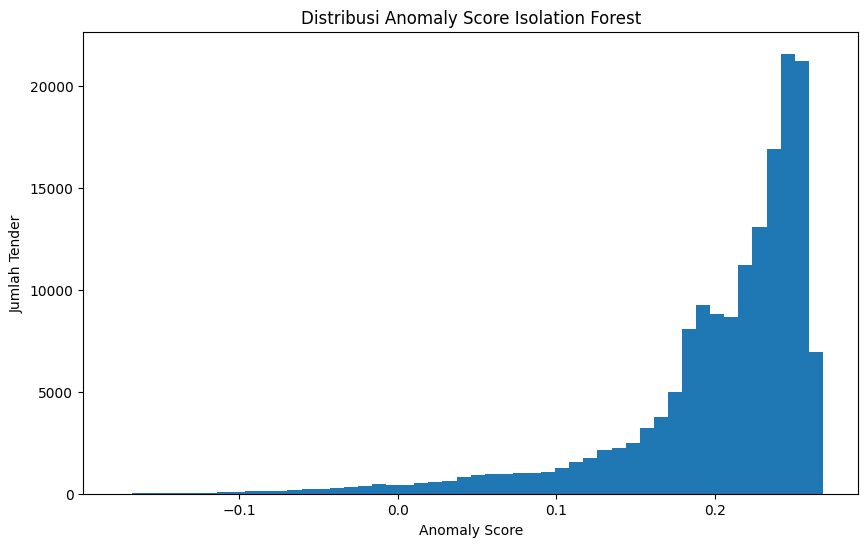

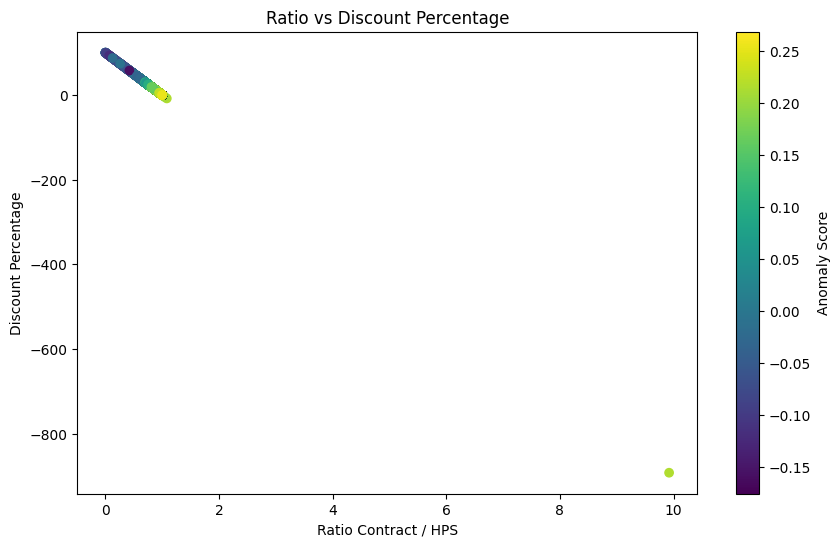

TOP SUSPICIOUS VENDORS
vendor_name
Firma KJSB Subkhi Abdul Hakim At Tigholy dan Rekan   -0.158629
PT. ENSEVAL PUTERA MEGATRADING. Tbk                  -0.151866
PT.BIOGEN SCIENTIFIC                                 -0.149281
PT. ENSEVAL PUTERA MEGATRADING, Tbk                  -0.147734
PT BRANTAS ABIPRAYA (Persero)                        -0.141380
PT. Pembangunan Perumahan (Persero)  Tbk             -0.139737
PT. WASKITA KARYA (PERSERO) Tbk                      -0.131909
PT ADHI KARYA (Persero) Tbk                          -0.123318
Admiral Blesensa Abadi                               -0.121421
PT. MITRA FAJAR SELARAS                              -0.119931
Name: anomaly_score, dtype: float64


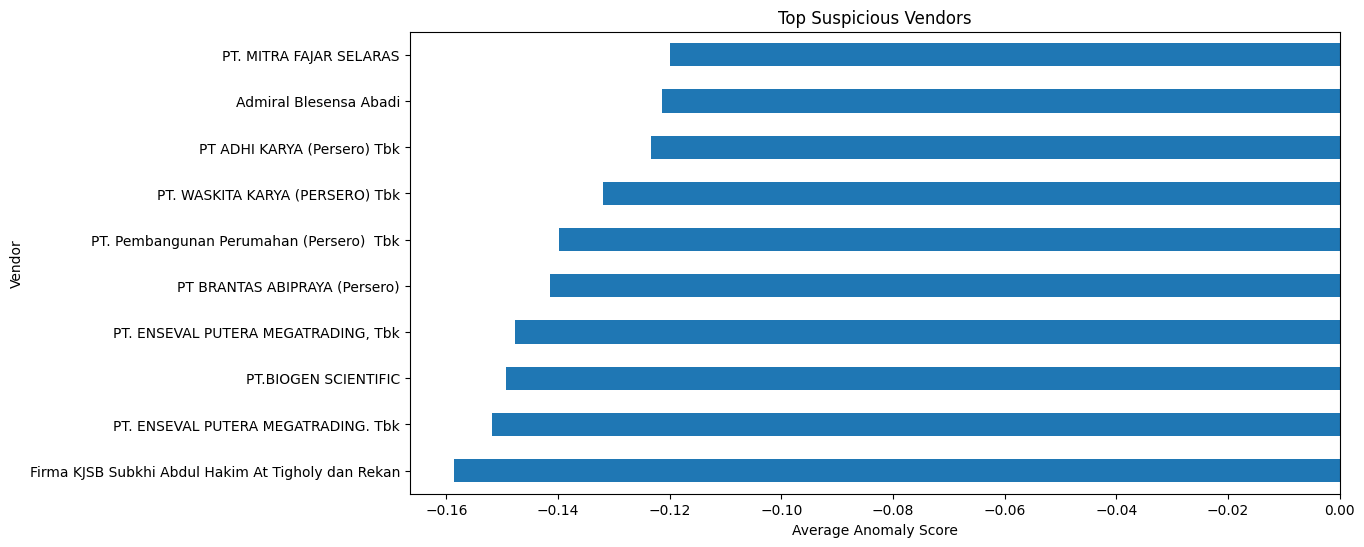

INSTANSI PALING RAWAN

buyer_name
PDAM Delta Tirta Sidoarjo                                   0.049226
PD BKK Kesugihan Kabupaten Cilacap                          0.049560
Badan Pusat Statistik                                       0.062621
Lembaga Perlindungan Saksi dan Korban Republik Indonesia    0.067784
Kementerian Pekerjaan Umum dan Perumahan Rakyat             0.084821
Pemerintah Daerah Kota Denpasar                             0.091077
Pemerintah Daerah Kabupaten Jayawijaya                      0.092993
PDAM Kabupaten Semarang                                     0.095726
PDAM Tirtamarta Yogyakarta                                  0.098016
Kejaksaan Republik Indonesia                                0.103440
Name: anomaly_score, dtype: float64


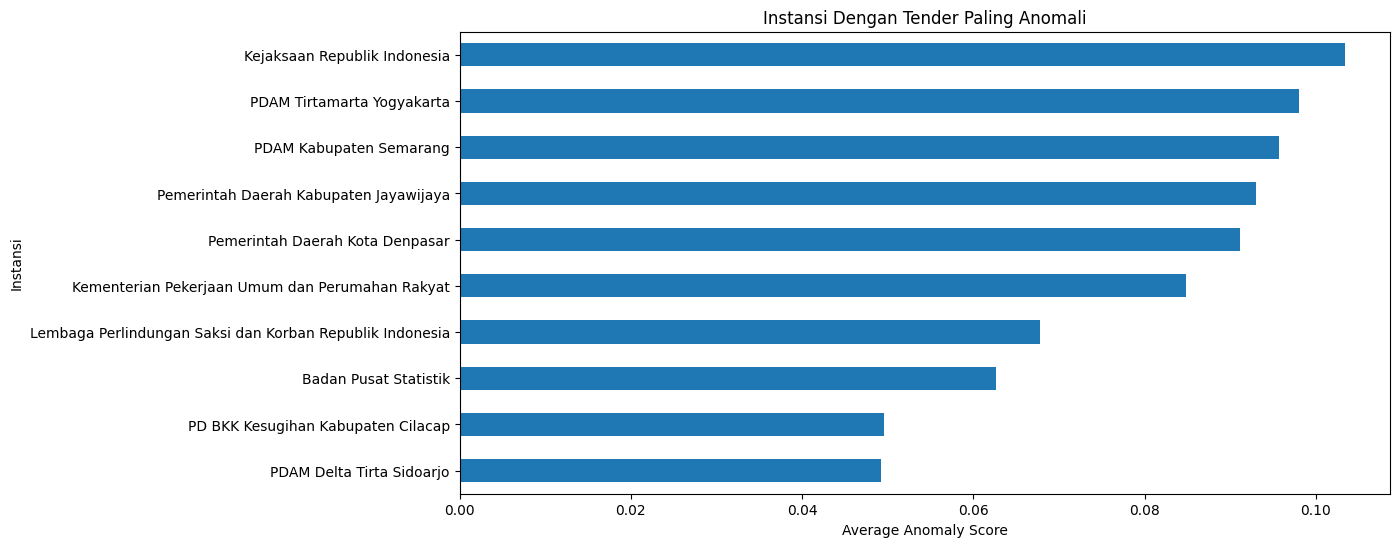

VENDOR DOMINANCE

vendor_name
PT. ALOCITA MANDIRI                        153
PT. Gumilang Sajati                        143
PT. ARTEK UTAMA                            120
PT. GANESHA PRATAMA CONSULTANT             116
CV. TIKA KREATIF DESAIN KONSULTAN          109
PT. DUTA BHUANA JAYA                        97
PT. WANDRA CIPTA ENGINEERING CONSULTANT     94
PT. INKONEKSI IZI KONSULTAN                 92
PT. Inasa Sakha Kirana                      91
PT. DARMASRAYA MITRA AMERTA                 90
Name: count, dtype: int64


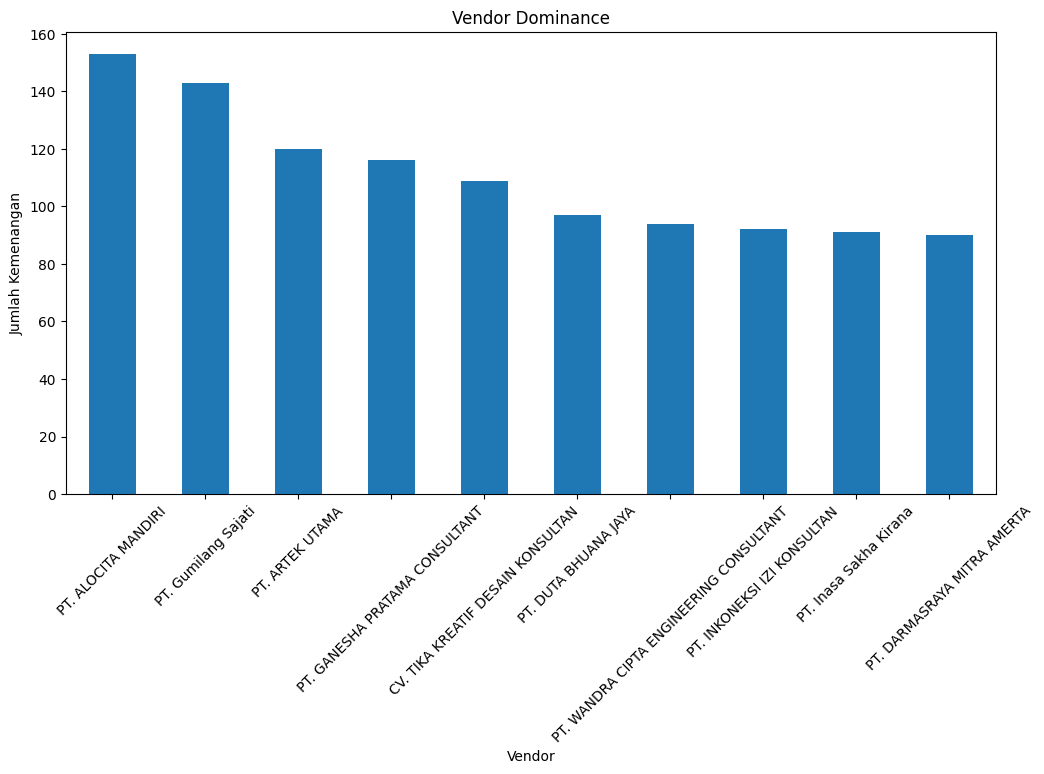

TOP 20 MOST SUSPICIOUS TENDERS

                                     vendor_name  \
56104              PT BRANTAS ABIPRAYA (Persero)   
74555              PT BRANTAS ABIPRAYA (Persero)   
74429              PT BRANTAS ABIPRAYA (Persero)   
19847              PT BRANTAS ABIPRAYA (Persero)   
37721              PT BRANTAS ABIPRAYA (Persero)   
95543              PT BRANTAS ABIPRAYA (Persero)   
99362                          SAPTA KARYA ABADI   
74557            PT. WASKITA KARYA (PERSERO) Tbk   
95512            PT. WASKITA KARYA (PERSERO) Tbk   
38178   PT. Pembangunan Perumahan (Persero)  Tbk   
19684            PT. WASKITA KARYA (PERSERO) Tbk   
37893   PT. Pembangunan Perumahan (Persero)  Tbk   
38105              PT BRANTAS ABIPRAYA (Persero)   
117038  PT. Pembangunan Perumahan (Persero)  Tbk   
74790   PT. Pembangunan Perumahan (Persero)  Tbk   
138575  PT. Pembangunan Perumahan (Persero)  Tbk   
74831   PT. Pembangunan Perumahan (Persero)  Tbk   
74430                 PT. NINDYA

In [30]:
# VISUALIZATION & DASHBOARD
# Isolation Forest Fraud Detection

import pandas as pd
import matplotlib.pyplot as plt

# 1. HISTOGRAM ANOMALY SCORE

plt.figure(figsize=(10,6))

plt.hist(
    df_model["anomaly_score"],
    bins=50
)

plt.xlabel("Anomaly Score")
plt.ylabel("Jumlah Tender")
plt.title("Distribusi Anomaly Score Isolation Forest")

plt.show()

# 2. SCATTER PLOT
# Ratio vs Discount Percentage

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df_model["ratio"],
    df_model["discount_percentage"],
    c=df_model["anomaly_score"]
)

plt.xlabel("Ratio Contract / HPS")
plt.ylabel("Discount Percentage")
plt.title("Ratio vs Discount Percentage")

plt.colorbar(scatter, label="Anomaly Score")

plt.show()

# 3. TOP SUSPICIOUS VENDORS

top_suspicious_vendors = (
    df_model.groupby("vendor_name")["anomaly_score"]
    .mean()
    .sort_values()
    .head(10)
)

print("TOP SUSPICIOUS VENDORS")
print(top_suspicious_vendors)

# VISUALISASI TOP SUSPICIOUS VENDORS

plt.figure(figsize=(12,6))

top_suspicious_vendors.plot(kind="barh")

plt.xlabel("Average Anomaly Score")
plt.ylabel("Vendor")
plt.title("Top Suspicious Vendors")

plt.show()

# 4. INSTANSI RAWAN

risky_agencies = (
    df_model.groupby("buyer_name")["anomaly_score"]
    .mean()
    .sort_values()
    .head(10)
)

print("INSTANSI PALING RAWAN\n")

print(risky_agencies)

# VISUALISASI INSTANSI RAWAN

plt.figure(figsize=(12,6))

risky_agencies.plot(kind="barh")

plt.xlabel("Average Anomaly Score")
plt.ylabel("Instansi")
plt.title("Instansi Dengan Tender Paling Anomali")

plt.show()

# 5. VENDOR DOMINANCE

vendor_dominance = (
    df_model["vendor_name"]
    .value_counts()
    .head(10)
)
print("VENDOR DOMINANCE\n")

print(vendor_dominance)

# VISUALISASI VENDOR DOMINANCE

plt.figure(figsize=(12,6))

vendor_dominance.plot(kind="bar")

plt.xlabel("Vendor")
plt.ylabel("Jumlah Kemenangan")
plt.title("Vendor Dominance")

plt.xticks(rotation=45)

plt.show()

# 6. TOP ANOMALY TABLE
top_anomalies = df_model.sort_values(
    by="anomaly_score"
).head(20)

print("TOP 20 MOST SUSPICIOUS TENDERS\n")

print(
    top_anomalies[
        [
            "vendor_name",
            "buyer_name",
            "HPS",
            "contract_value",
            "ratio",
            "discount_percentage",
            "vendor_win_count",
            "anomaly_score"
        ]
    ]
)
# OPTIONAL SAVE
top_anomalies.to_csv(
    "top_suspicious_tenders.csv",
    index=False
)

print("\nDashboard & visualisasi selesai.")

# Model LOCAL OUTLIER FACTOR 

In [31]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

In [32]:
#Pilih features yang relevan untuk LOF
features = [
    "HPS",
    "contract_value",
    "ratio",
    "discount_percentage",
    "vendor_win_count",
    "vendor_instansi_frequency",
    "avg_vendor_ratio"
]
X = df_data[features]

In [33]:
#Handling misssing values
X = X.dropna()
df_lof = df_data.loc[X.index].copy()

In [34]:
#scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [35]:
#Train local outlier factor
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

In [36]:
#fut and save a prediction
lof_labels = lof.fit_predict(X_scaled)

df_lof["lof_label"] = lof_labels

In [37]:
#Anomaly score (negative_outlier_factor_)
#semakin negatif, semakin anomali
df_lof["lof_score"] = lof.negative_outlier_factor_

In [38]:
print("LOF anomaly detection selesai.\n")
print(df_lof["lof_label"].value_counts())

LOF anomaly detection selesai.

lof_label
 1    158193
-1      3229
Name: count, dtype: int64


In [39]:
# =========================================================
# 9. TOP ANOMALIES
# =========================================================

top_lof_anomalies = (
    df_lof
    .sort_values(by="lof_score")
    .head(20)
)

print("\n===================================")
print("TOP LOF ANOMALIES")
print("===================================\n")

print(
    top_lof_anomalies[
        [
            "vendor_name",
            "buyer_name",
            "HPS",
            "contract_value",
            "ratio",
            "discount_percentage",
            "vendor_win_count",
            "vendor_instansi_frequency",
            "avg_vendor_ratio",
            "lof_score"
        ]
    ]
)


TOP LOF ANOMALIES

                                           vendor_name  \
95820                                  Gilang Gemilang   
1628                                PT. CITRA SHIPYARD   
55863                               PT. CITRA SHIPYARD   
61006                       PT.HASTI ANUGRAH NUSANTARA   
82097   KOPERASI KONSUMEN PUSAT KOPERASI KARTIKA TIDAR   
154813                            PT. ARKAN PUTRA TAMA   
112007                            PT. TRIMURTI PERKASA   
1584                     PT. Trinika Teknologi Mandiri   
77434                       CV. BENUM GEMILANG MANDIRI   
101031  KOPERASI KONSUMEN PUSAT KOPERASI KARTIKA TIDAR   
49073                            CV Bintang Bima Sakti   
32086                                      ubay dillah   
108262                              CV. CAHAYA BERLIAN   
119634                           CV. DANADYAKSA IHATRA   
86101                                      Geotrimukti   
62662                            PT SARANA NIKITA JA

In [40]:
# =========================================================
# 10. SAVE HASIL
# =========================================================

top_lof_anomalies.to_csv(
    "top_lof_anomalies.csv",
    index=False
)

print("\nLOF modeling selesai.")


LOF modeling selesai.


In [41]:
if_anomalies = df_model[
    df_model["anomaly_label"] == -1
]
lof_anomalies = df_lof[
    df_lof["lof_label"] == -1
]

In [42]:
common_vendors = set(
    if_anomalies["vendor_name"]
).intersection(
    set(lof_anomalies["vendor_name"])
)

print("Jumlah vendor overlap:", len(common_vendors))

print(common_vendors)

Jumlah vendor overlap: 223
{'PT. TEKNOLOGY CIPTA KARYA', 'PT. RAYAKONSULT', 'PT PURA BARUTAMA', 'PT. PRIVINDO AKWILA', 'PT Nata Loka Abadi', 'PT. DIAN PERDANA KARSA', 'PT. DEWI GRAHA INDAH', 'FELINDO MITRA ABADI', 'PT. SANTOSO SHAFANARA GRAHA', 'PT. Mandiri Agung Papua', 'PT. GALEN SAGARA PERKASA', 'PT. MARI BANGUN NUSANTARA', 'PT. SRI REJEKI ISMAN, Tbk', 'PT. TEMPRINA MEDIA GRAFIKA', 'PT. Infosys Solusi Terpadu', 'PT. Makmur Sehati Sejahtera', 'PT.HASTI ANUGRAH NUSANTARA', 'CV. KARYA AMALIA', 'PT AGUNG JAYA SEJAHTERA', 'PT. Multijaya Sparindo', 'PT. Budi Jaya Persada', 'CV. ADI MERTHA', 'SAPTA KARYA ABADI', 'PT. WIRATAMA KARYA NUGRAHA', 'PT. BINTANG SURYA TUNAS MANDIRI', 'PT. ARCAMANIK MUSTIKA FARMA', 'PT Total Indo Bangunusa', 'GURILA SAKTI', 'PT. BINTANG INTI REKATAMA', 'PT. MANIK TRIBUWANA', 'CV.CITRA AJYAD', 'PT. ANEKA PUNDITIRTA', 'CV. Delina', 'PT. TRIJAYA NUSANTARA ABADI', 'PT. MULTI MAJU SEJAHTERA', 'PT. WIJAYA KARYA BANGUNAN GEDUNG', 'PT. Rajendra Pratama Jaya', 'CV ARYA DEWA

In [43]:
print(
    if_anomalies[
        ["ratio", "discount_percentage"]
    ].describe()
)

print(
    lof_anomalies[
        ["ratio", "discount_percentage"]
    ].describe()
)

             ratio  discount_percentage
count  3229.000000          3229.000000
mean      0.803070            19.692967
std       0.198784            19.878396
min       0.000700             0.000000
25%       0.744200             4.440000
50%       0.844100            15.590000
75%       0.955600            25.580000
max       1.000000            99.930000
             ratio  discount_percentage
count  3229.000000          3229.000000
mean      0.888851            11.114899
std       0.191167            19.116684
min       0.000700          -892.160000
25%       0.800000             1.500000
50%       0.902200             9.780000
75%       0.985000            20.000000
max       9.921600            99.930000


In [44]:
common_df = df_model[
    df_model["vendor_name"].isin(common_vendors)
]

In [45]:
top_common = (
    common_df.groupby("vendor_name")
    ["anomaly_score"]
    .mean()
    .sort_values()
    .head(20)
)

print(top_common)

vendor_name
Firma KJSB Subkhi Abdul Hakim At Tigholy dan Rekan   -0.158629
PT. ENSEVAL PUTERA MEGATRADING. Tbk                  -0.151866
PT.BIOGEN SCIENTIFIC                                 -0.149281
PT. ENSEVAL PUTERA MEGATRADING, Tbk                  -0.147734
PT BRANTAS ABIPRAYA (Persero)                        -0.141380
PT. Pembangunan Perumahan (Persero)  Tbk             -0.139737
PT. WASKITA KARYA (PERSERO) Tbk                      -0.131909
PT. HUTAMA KARYA (PERSERO)                           -0.119263
PT. NINDYA KARYA (Persero)                           -0.117022
PT. WIJAYA KARYA (Persero) Tbk.                      -0.116356
BANGKIT BERKAH PERKASA                               -0.116120
CHINA CAMC ENGINEERING CO.,LTD                       -0.113786
PT. Revass Utama Medika                              -0.108678
PT. Paragon Prima Karya                              -0.107051
PT. CENDANA TIRTA PERSADA                            -0.101708
PT. ADHI KARYA (Persero) Tbk               

# EVALUASI

In [46]:
from sklearn.metrics import silhouette_score

def evaluasi_statistik(X, labels, model_name):
    # Gunakan sample_size agar komputasi selesai dalam beberapa detik
    # random_state=42 digunakan agar hasil sampling selalu konsisten/sama saat di-rerun
    score = silhouette_score(X, labels, sample_size=20000, random_state=42)
    
    print(f"--- Statistik Evaluasi: {model_name} ---")
    print(f"Silhouette Score (Sampled 20k): {score:.4f}")
    
    # Menghitung persentase anomali yang dideteksi (tetap dihitung dari total data)
    n_anomali = (labels == -1).sum()
    persentase = (n_anomali / len(labels)) * 100
    print(f"Jumlah Anomali Terdeteksi: {n_anomali} dari {len(labels)} total data ({persentase:.2f}%)")
    print("-" * 30)

# EKSEKUSI
evaluasi_statistik(X_scaled, df_model["anomaly_label"], "Isolation Forest")
evaluasi_statistik(X_scaled, df_lof["lof_label"], "Local Outlier Factor")

--- Statistik Evaluasi: Isolation Forest ---
Silhouette Score (Sampled 20k): 0.6768
Jumlah Anomali Terdeteksi: 3229 dari 161422 total data (2.00%)
------------------------------
--- Statistik Evaluasi: Local Outlier Factor ---
Silhouette Score (Sampled 20k): 0.2692
Jumlah Anomali Terdeteksi: 3229 dari 161422 total data (2.00%)
------------------------------


In [47]:
#VALIDASI KONSISTENSI ANTARA IF & LOF
from sklearn.metrics import jaccard_score

def validasi_konsistensi(labels_a, labels_b):
    # Ubah format: 1 (normal) menjadi 0, -1 (anomali) menjadi 1
    a_binary = np.where(labels_a == -1, 1, 0)
    b_binary = np.where(labels_b == -1, 1, 0)
    
    # 1. Jaccard Similarity (Irisan antara dua model)
    # Mengukur seberapa mirip set anomali yang ditemukan IF dan LOF
    jaccard = jaccard_score(a_binary, b_binary, average='micro')
    
    # 2. Overlap Ratio (Persentase konsistensi)
    # Dari semua anomali yang ditemukan model A, berapa yang ditemukan juga oleh B
    intersection = np.sum((a_binary == 1) & (b_binary == 1))
    overlap_a = (intersection / np.sum(a_binary)) * 100
    overlap_b = (intersection / np.sum(b_binary)) * 100
    
    print("--- Validasi Konsistensi IF vs LOF ---")
    print(f"Jaccard Similarity Score: {jaccard:.4f}")
    print(f"Persentase Anomali IF yang juga ditemukan LOF: {overlap_a:.2f}%")
    print(f"Persentase Anomali LOF yang juga ditemukan IF: {overlap_b:.2f}%")
    
    # Rekomendasi: Gunakan observasi yang disepakati kedua model sebagai 'High Risk'
    high_risk_indices = np.where((a_binary == 1) & (b_binary == 1))[0]
    print(f"Total Sampel Konsisten (High Risk): {len(high_risk_indices)}")

validasi_konsistensi(if_anomalies["anomaly_label"], lof_anomalies["lof_label"])

--- Validasi Konsistensi IF vs LOF ---
Jaccard Similarity Score: 1.0000
Persentase Anomali IF yang juga ditemukan LOF: 100.00%
Persentase Anomali LOF yang juga ditemukan IF: 100.00%
Total Sampel Konsisten (High Risk): 3229


In [48]:
import numpy as np
import pandas as pd
from sklearn.metrics import jaccard_score

def validasi_konsistensi(labels_a, labels_b):
    # Ubah format: 1 (normal) menjadi 0, -1 (anomali) menjadi 1
    a_binary = np.where(labels_a == -1, 1, 0)
    b_binary = np.where(labels_b == -1, 1, 0)
    
    # 1. Jaccard Similarity (tanpa parameter average agar murni menghitung irisan kelas 1)
    jaccard = jaccard_score(a_binary, b_binary)
    
    # 2. Overlap Ratio (Persentase konsistensi)
    intersection = np.sum((a_binary == 1) & (b_binary == 1))
    overlap_a = (intersection / np.sum(a_binary)) * 100
    overlap_b = (intersection / np.sum(b_binary)) * 100
    
    print("--- Validasi Konsistensi IF vs LOF ---")
    print(f"Jaccard Similarity Score: {jaccard:.4f}")
    print(f"Persentase Anomali IF yang juga ditemukan LOF: {overlap_a:.2f}%")
    print(f"Persentase Anomali LOF yang juga ditemukan IF: {overlap_b:.2f}%")
    
    # Ekstraksi index baris yang KEDUA model sepakat bernilai anomali (1)
    high_risk_indices = np.where((a_binary == 1) & (b_binary == 1))[0]
    print(f"Total Sampel Konsisten (High Risk): {len(high_risk_indices)}")
    
    return high_risk_indices

# 1. EKSEKUSI PADA DATAFRAME UTAMA YANG UTUH
# Pastikan urutan baris df_model dan df_lof sejajar/identik
high_risk_idx = validasi_konsistensi(df_model["anomaly_label"], df_lof["lof_label"])

# 2. EKSTRAKSI DATA ASLI UNTUK INVESTIGASI / NETWORK ANALYSIS
# Ambil baris dari dataframe aslimu berdasarkan index yang konsisten
df_high_risk = df_model.iloc[high_risk_idx]

# Tampilkan sampel datanya untuk memastikan
print("\n--- Sampel Data Tender 'Super Anomaly' (High Risk) ---")
display(df_high_risk.head())

--- Validasi Konsistensi IF vs LOF ---
Jaccard Similarity Score: 0.0406
Persentase Anomali IF yang juga ditemukan LOF: 7.80%
Persentase Anomali LOF yang juga ditemukan IF: 7.80%
Total Sampel Konsisten (High Risk): 252

--- Sampel Data Tender 'Super Anomaly' (High Risk) ---


,ocid,buyer_name,vendor_name,HPS,contract_value,category,item_description,date,ratio,discount_percentage,vendor_win_count,vendor_instansi_frequency,avg_vendor_ratio,anomaly_label,anomaly_score
117,ocds-20h3g7-16685025,Kementerian Pendidikan dan Kebudayaan,PT. GRAMEDIA,2.348619e+10,1.838557e+10,services,Jasa Lainnya,2024-03-01,0.7828,21.72,7,7,0.6994,-1,-0.054949
124,ocds-20h3g7-16835025,Kementerian Pendidikan dan Kebudayaan,PT. CABE RAYA NUSANTARA EXPRESS,7.203081e+09,5.068440e+09,services,Jasa Lainnya,2024-04-18,0.7036,29.64,1,1,0.7036,-1,-0.003733
567,ocds-20h3g7-41224011,Kementerian Keuangan,PT NUSANTARA COMPNET INTEGRATOR,2.592272e+10,1.459144e+10,goods,Pengadaan Barang,2024-10-10,0.5629,43.71,20,6,0.9368,-1,-0.060157
649,ocds-20h3g7-7358024,Pemerintah Daerah Kota Banjarmasin,CV. TIKA KREATIF DESAIN KONSULTAN,2.360460e+08,1.719090e+08,services,Jasa Konsultansi Badan Usaha Konstruksi,2024-05-23,0.7283,27.17,109,4,0.9638,-1,-0.032162
827,ocds-20h3g7-16684025,Kementerian Pendidikan dan Kebudayaan,PT. MACANANJAYA CEMERLANG,2.703998e+10,2.109204e+10,services,Jasa Lainnya,2024-03-01,0.7800,22.00,5,5,0.6990,-1,-0.062784


In [49]:
# ============================================================
# ADVANCED NETWORK ANALYSIS: SUPER ANOMALY INVESTIGATION
# FOCUS: 252 HIGH-RISK SAMPLES (IF + LOF INTERSECTION)
# ============================================================

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network
import community.community_louvain as community_louvain # pip install python-louvain

# 1. PREPARE DATA (Gunakan hasil irisan 252 data)
# ------------------------------------------------------------
# Asumsi: df_high_risk adalah dataframe berisi 252 baris hasil irisan IF & LOF
print(f"Analyzing {len(df_high_risk)} Super Anomaly samples...")

G = nx.Graph()

# 2. BUILD GRAPH
# ------------------------------------------------------------
# Kita menggunakan 'weight' sebagai jumlah tender antara vendor & buyer tertentu
edge_data = (
    df_high_risk.groupby(["vendor_name", "buyer_name"], as_index=False)
    .agg({"contract_value": "sum", "ocid": "count"})
    .rename(columns={"ocid": "weight"})
)

for row in edge_data.itertuples(index=False):
    v_node = f"V: {row.vendor_name}"
    b_node = f"B: {row.buyer_name}"
    
    G.add_node(v_node, node_type="vendor")
    G.add_node(b_node, node_type="buyer")
    G.add_edge(v_node, b_node, weight=row.weight, value=row.contract_value)

print(f"Graph Created: {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

# 3. ADVANCED METRICS CALCULATION
# ------------------------------------------------------------
print("Calculating Centrality, Clustering, and Communities...")

# Degree Centrality (Dominansi)
degree_cent = nx.degree_centrality(G)

# Betweenness Centrality (Jembatan Broker)
between_cent = nx.betweenness_centrality(G)

# Clustering Coefficient (Potensi Clique/Kartel)
clustering_coeff = nx.clustering(G)

# Community Detection (Louvain Method)
partition = community_louvain.best_partition(G)

# 4. CONSOLIDATE RESULTS TO DATAFRAME
# ------------------------------------------------------------
results = []
for node in G.nodes():
    results.append({
        "node": node,
        "type": "Vendor" if node.startswith("V:") else "Buyer",
        "name": node.replace("V: ", "").replace("B: ", ""),
        "degree_centrality": degree_cent[node],
        "betweenness_centrality": between_cent[node],
        "clustering_coefficient": clustering_coeff[node],
        "community_id": partition[node]
    })

df_metrics = pd.DataFrame(results)

# 5. EXPORT TOP RISK VENDORS
# ------------------------------------------------------------
# Fokus pada vendor dengan clustering tinggi (potensi kartel)
top_risk_vendors = df_metrics[df_metrics["type"] == "Vendor"].sort_values(
    by=["clustering_coefficient", "degree_centrality"], ascending=False
)

print("\n--- Top Risk Vendors (High Clustering & Dominance) ---")
print(top_risk_vendors.head(10))

# 6. PYVIS INTERACTIVE VISUALIZATION
# ------------------------------------------------------------
print("\nGenerating Interactive Visualization...")

net = Network(height="800px", width="100%", bgcolor="#ffffff", font_color="black")

# Gunakan palet warna untuk komunitas
community_colors = [
    "#e74c3c", "#3498db", "#2ecc71", "#f1c40f", "#9b59b6", 
    "#1abc9c", "#e67e22", "#34495e", "#95a5a6", "#d35400"
]

for n in G.nodes():
    c_id = partition[n]
    color = community_colors[c_id % len(community_colors)]
    shape = "dot" if n.startswith("V:") else "diamond"
    
    # Ukuran berdasarkan Degree Centrality
    size = 15 + (degree_cent[n] * 100)
    
    net.add_node(
        n, 
        label=df_metrics.loc[df_metrics['node']==n, 'name'].values[0],
        color=color,
        shape=shape,
        size=size,
        title=(f"Type: {n[:1]}<br>Community: {c_id}<br>"
               f"Clustering: {clustering_coeff[n]:.4f}<br>"
               f"Degree: {degree_cent[n]:.4f}")
    )

for u, v, d in G.edges(data=True):
    net.add_edge(u, v, value=d['weight'], color="#bdc3c7", title=f"Wins: {d['weight']}")

net.set_options("""
var options = {
  "physics": {
    "forceAtlas2Based": {
      "gravitationalConstant": -100,
      "centralGravity": 0.01,
      "springLength": 100,
      "springConstant": 0.08
    },
    "minVelocity": 0.75,
    "solver": "forceAtlas2Based"
  }
}
""")

net.write_html("super_anomaly_network.html")
print("Interactive graph saved as 'super_anomaly_network.html'")

# 7. EXPORT FOR REPORT
# ------------------------------------------------------------
df_metrics.to_csv("network_analysis_results.csv", index=False)

Analyzing 252 Super Anomaly samples...
Graph Created: 191 nodes and 173 edges.
Calculating Centrality, Clustering, and Communities...

--- Top Risk Vendors (High Clustering & Dominance) ---
                                      node    type  \
153  V: PT. Telekomunikasi Indonesia, Tbk.  Vendor   
118            V: PT. MITRA SOLUSI INFOKOM  Vendor   
123            V: PT. MULTI MAJU SEJAHTERA  Vendor   
147    V: PT. SURVEYOR INDONESIA (PERSERO)  Vendor   
45             V: PT APLIKANUSA LINTASARTA  Vendor   
65         V: PT. ADHI KARYA (Persero) Tbk  Vendor   
96       V: PT. GANESHA PRATAMA CONSULTANT  Vendor   
165          V: PT. Virama Karya (Persero)  Vendor   
167     V: PT. WASKITA KARYA (PERSERO) Tbk  Vendor   
173           V: PT. YODYA KARYA (PERSERO)  Vendor   

                                   name  degree_centrality  \
153  PT. Telekomunikasi Indonesia, Tbk.           0.063158   
118            PT. MITRA SOLUSI INFOKOM           0.015789   
123            PT. MULTI MAJU

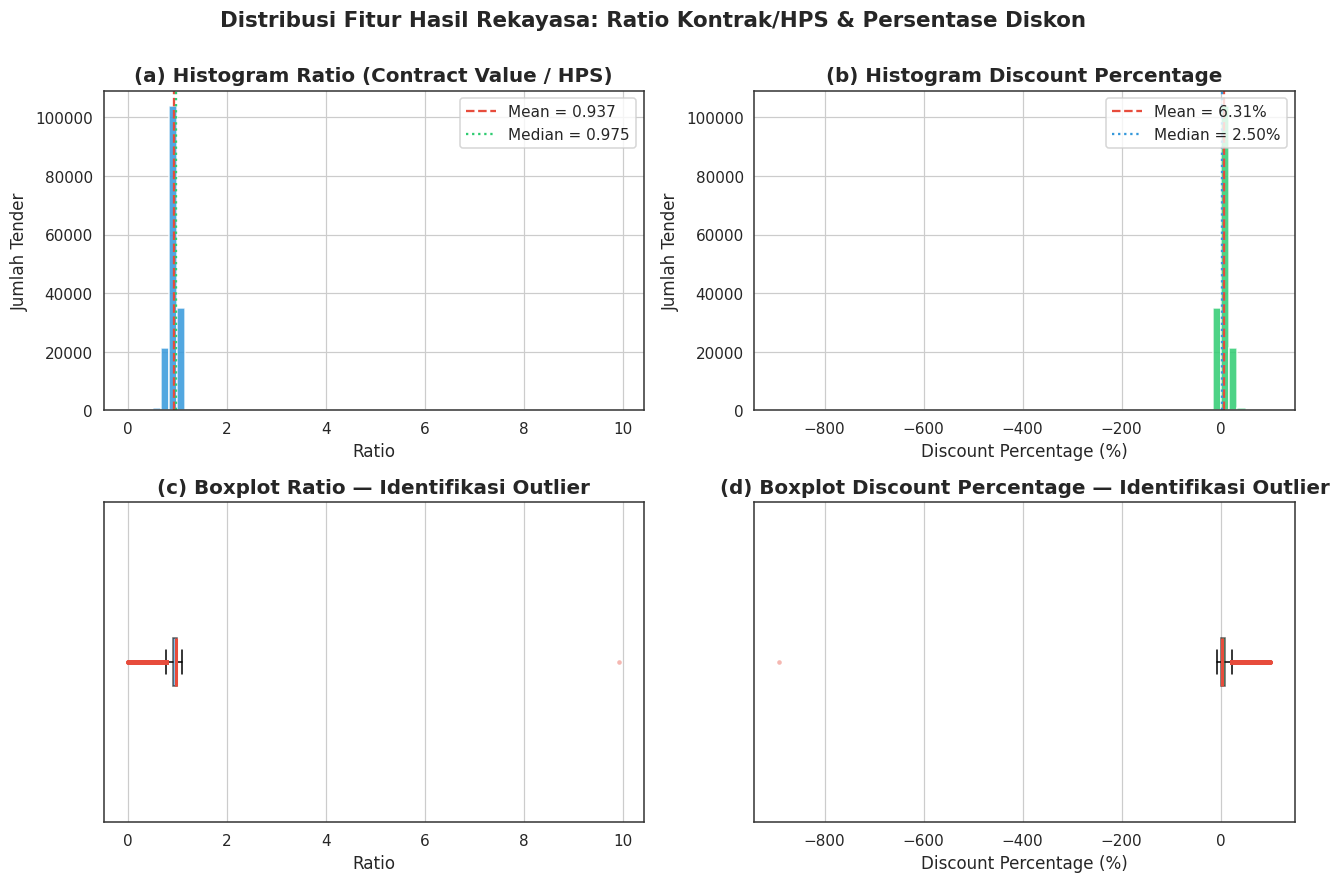

✓ Gambar 5 tersimpan: Gambar5_Sebaran_Fitur.png


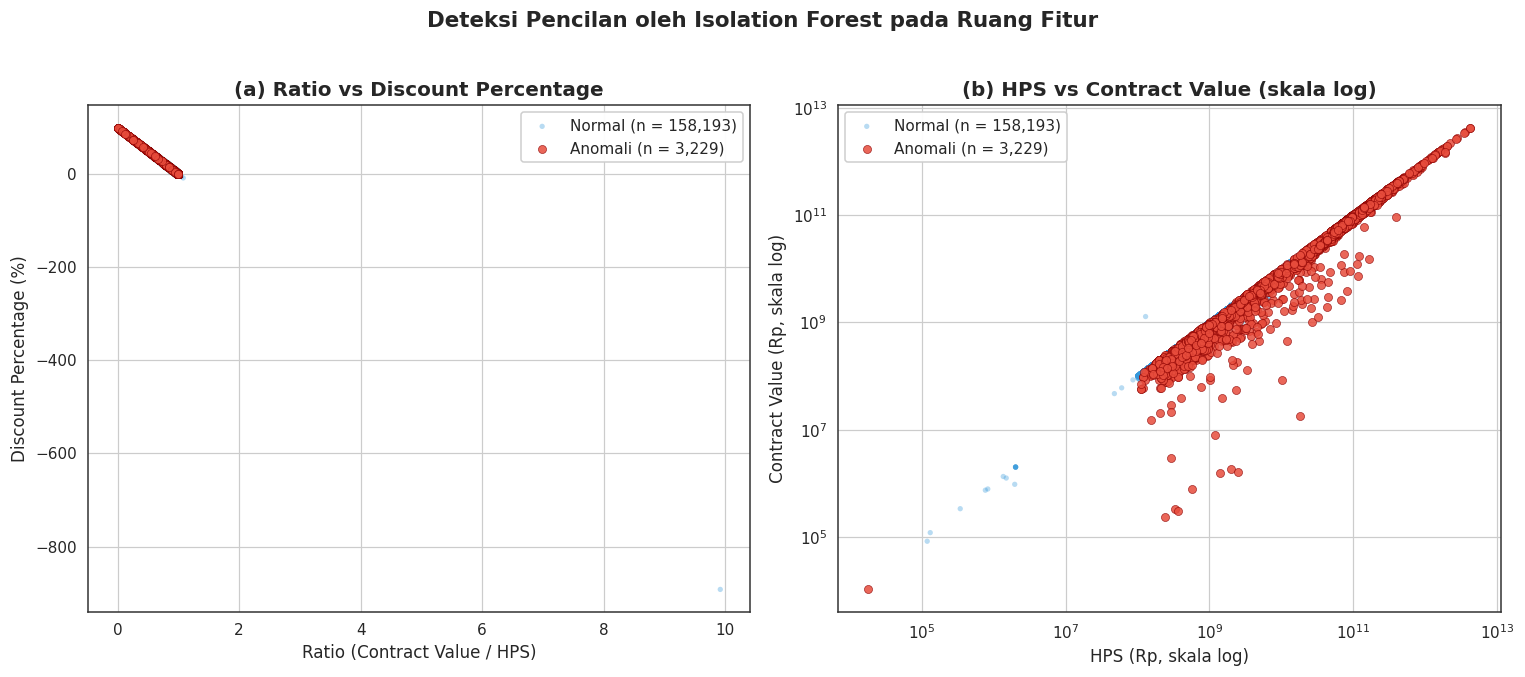

✓ Gambar 6 tersimpan: Gambar6_Pencilan_IsolationForest.png


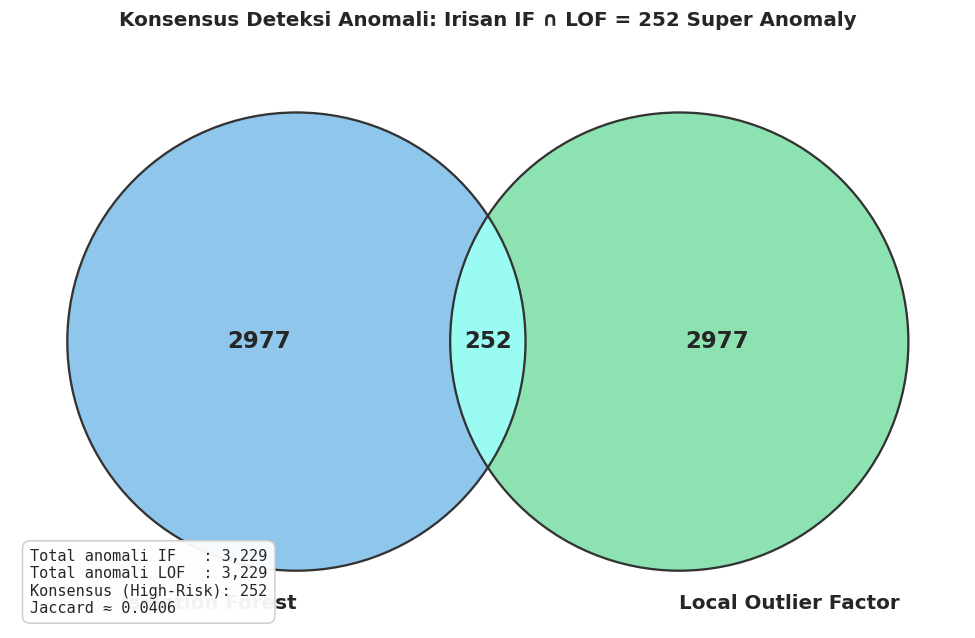

✓ Gambar 7a tersimpan: Gambar7a_Venn_Konsensus.png


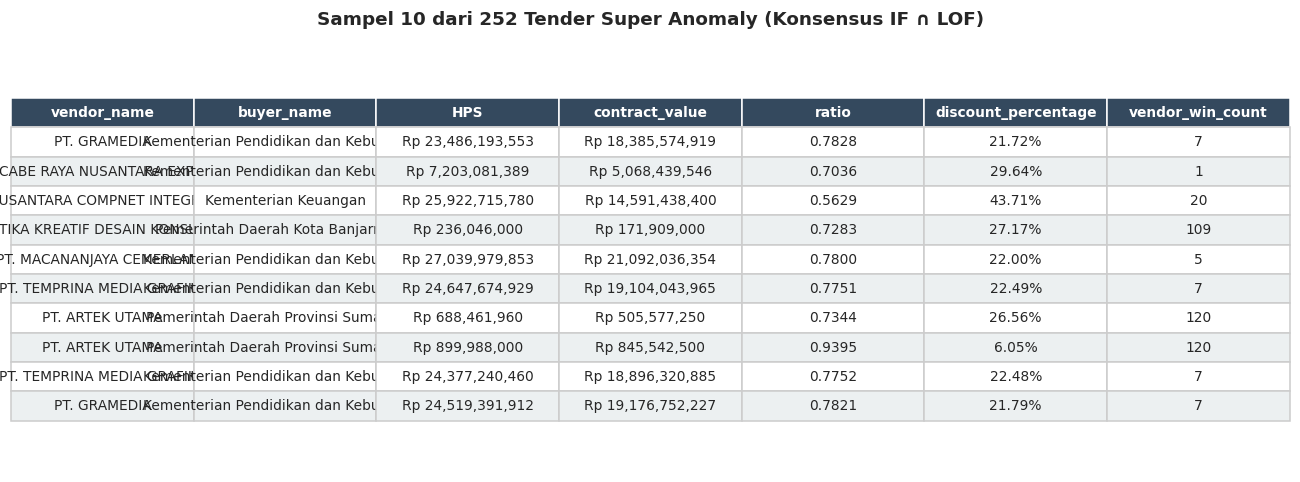

✓ Gambar 7b tersimpan: Gambar7b_Sampel_HighRisk.png


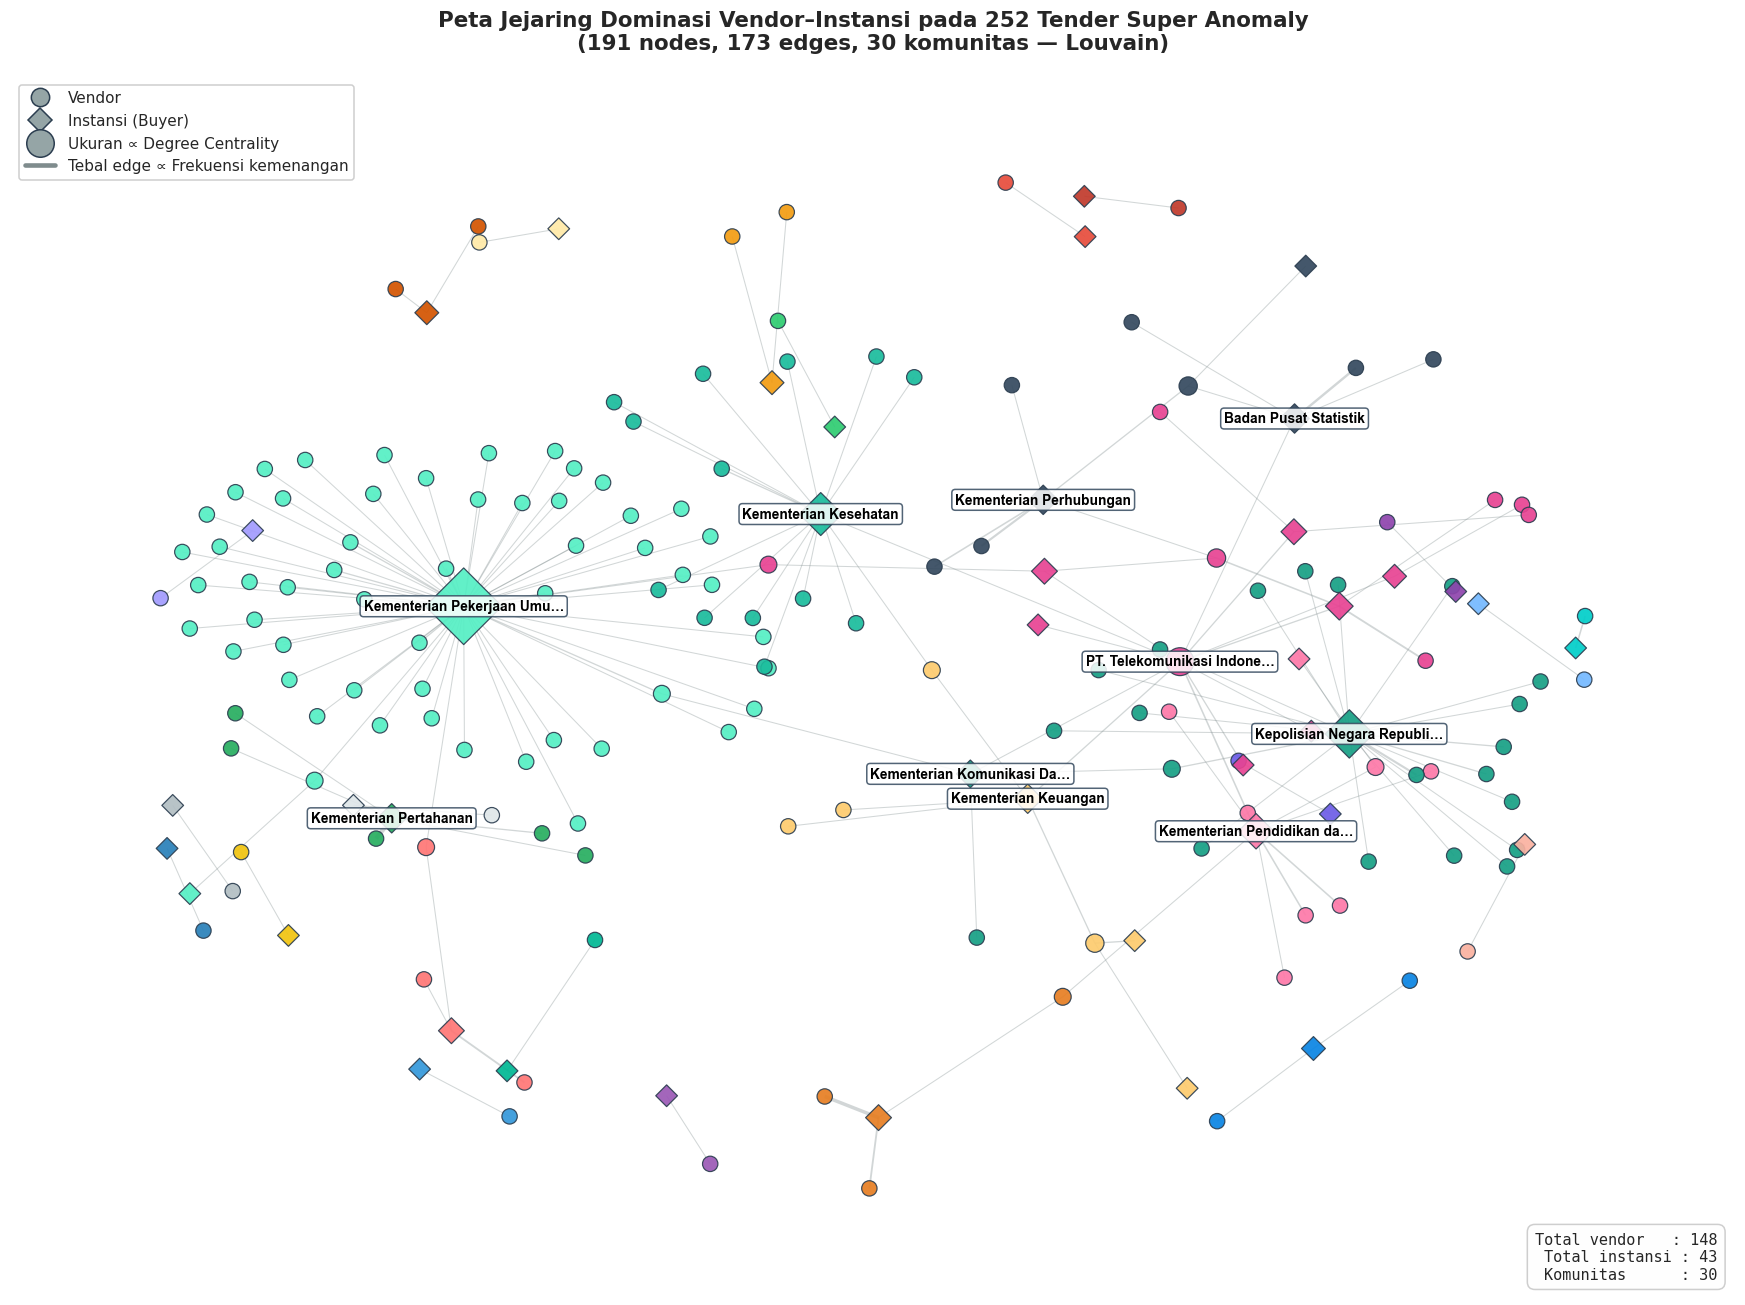

✓ Gambar 8 tersimpan: Gambar8_Network_VendorInstansi.png

SEMUA VISUALISASI SELESAI DIBUAT.


In [50]:
# ============================================================================
# VISUALISASI MAKALAH — Deteksi Anomali Tender Pengadaan
# ----------------------------------------------------------------------------
# Jalankan SETELAH seluruh cell di main.ipynb selesai dieksekusi.
# Variabel yang dibutuhkan dari notebook utama:
#   - df_data        : dataframe setelah feature engineering
#   - df_model       : dataframe + kolom 'anomaly_label' (Isolation Forest)
#   - df_lof         : dataframe + kolom 'lof_label' (LOF)
#   - df_high_risk   : 252 baris hasil irisan IF ∩ LOF
#   - G              : graph networkx
#   - partition      : hasil community_louvain.best_partition(G)
#   - degree_cent    : nx.degree_centrality(G)
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib_venn import venn2, venn2_circles   # pip install matplotlib-venn

# ---------------------------- STYLING GLOBAL ---------------------------------
sns.set_style("whitegrid")
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 1.0,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": True,
    "legend.edgecolor": "#cccccc",
})

COLOR_NORMAL  = "#3498db"
COLOR_ANOMALY = "#e74c3c"
COLOR_ACCENT  = "#2ecc71"
COLOR_NEUTRAL = "#95a5a6"


# ============================================================================
# GAMBAR 5 — SEBARAN FITUR HASIL REKAYASA  (Sub-bab 6.1)
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(
    "Distribusi Fitur Hasil Rekayasa: Ratio Kontrak/HPS & Persentase Diskon",
    fontsize=14, fontweight="bold", y=1.00
)

ratio_data    = df_data["ratio"].dropna()
discount_data = df_data["discount_percentage"].dropna()
r_mean, r_med = ratio_data.mean(),    ratio_data.median()
d_mean, d_med = discount_data.mean(), discount_data.median()

# (a) histogram ratio
ax = axes[0, 0]
ax.hist(ratio_data, bins=60, color=COLOR_NORMAL, edgecolor="white", alpha=0.85)
ax.axvline(r_mean, color=COLOR_ANOMALY, linestyle="--", linewidth=1.5, label=f"Mean = {r_mean:.3f}")
ax.axvline(r_med,  color=COLOR_ACCENT,  linestyle=":",  linewidth=1.5, label=f"Median = {r_med:.3f}")
ax.set_title("(a) Histogram Ratio (Contract Value / HPS)")
ax.set_xlabel("Ratio"); ax.set_ylabel("Jumlah Tender")
ax.legend(loc="upper right")

# (b) histogram discount
ax = axes[0, 1]
ax.hist(discount_data, bins=60, color=COLOR_ACCENT, edgecolor="white", alpha=0.85)
ax.axvline(d_mean, color=COLOR_ANOMALY, linestyle="--", linewidth=1.5, label=f"Mean = {d_mean:.2f}%")
ax.axvline(d_med,  color=COLOR_NORMAL,  linestyle=":",  linewidth=1.5, label=f"Median = {d_med:.2f}%")
ax.set_title("(b) Histogram Discount Percentage")
ax.set_xlabel("Discount Percentage (%)"); ax.set_ylabel("Jumlah Tender")
ax.legend(loc="upper right")

# (c) boxplot ratio
ax = axes[1, 0]
ax.boxplot(ratio_data, vert=False, patch_artist=True,
           boxprops=dict(facecolor=COLOR_NORMAL, alpha=0.6),
           medianprops=dict(color=COLOR_ANOMALY, linewidth=2),
           flierprops=dict(marker="o", markersize=3,
                           markerfacecolor=COLOR_ANOMALY,
                           markeredgecolor="none", alpha=0.4))
ax.set_title("(c) Boxplot Ratio — Identifikasi Outlier")
ax.set_xlabel("Ratio"); ax.set_yticks([])

# (d) boxplot discount
ax = axes[1, 1]
ax.boxplot(discount_data, vert=False, patch_artist=True,
           boxprops=dict(facecolor=COLOR_ACCENT, alpha=0.6),
           medianprops=dict(color=COLOR_ANOMALY, linewidth=2),
           flierprops=dict(marker="o", markersize=3,
                           markerfacecolor=COLOR_ANOMALY,
                           markeredgecolor="none", alpha=0.4))
ax.set_title("(d) Boxplot Discount Percentage — Identifikasi Outlier")
ax.set_xlabel("Discount Percentage (%)"); ax.set_yticks([])

plt.tight_layout()
plt.savefig("Gambar5_Sebaran_Fitur.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Gambar 5 tersimpan: Gambar5_Sebaran_Fitur.png")


# ============================================================================
# GAMBAR 6 — VISUALISASI PENCILAN ISOLATION FOREST  (Sub-bab 6.2)
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Deteksi Pencilan oleh Isolation Forest pada Ruang Fitur",
             fontsize=14, fontweight="bold", y=1.02)

normal_mask  = df_model["anomaly_label"] == 1
anomaly_mask = df_model["anomaly_label"] == -1
n_normal, n_anomaly = normal_mask.sum(), anomaly_mask.sum()

# (a) ratio vs discount
ax = axes[0]
ax.scatter(df_model.loc[normal_mask,  "ratio"],
           df_model.loc[normal_mask,  "discount_percentage"],
           c=COLOR_NORMAL, s=12, alpha=0.35,
           label=f"Normal (n = {n_normal:,})", edgecolors="none")
ax.scatter(df_model.loc[anomaly_mask, "ratio"],
           df_model.loc[anomaly_mask, "discount_percentage"],
           c=COLOR_ANOMALY, s=28, alpha=0.85,
           label=f"Anomali (n = {n_anomaly:,})",
           edgecolors="darkred", linewidth=0.4)
ax.set_xlabel("Ratio (Contract Value / HPS)")
ax.set_ylabel("Discount Percentage (%)")
ax.set_title("(a) Ratio vs Discount Percentage")
ax.legend(loc="best", framealpha=0.95)

# (b) HPS vs contract_value (log)
ax = axes[1]
ax.scatter(df_model.loc[normal_mask,  "HPS"],
           df_model.loc[normal_mask,  "contract_value"],
           c=COLOR_NORMAL, s=12, alpha=0.35,
           label=f"Normal (n = {n_normal:,})", edgecolors="none")
ax.scatter(df_model.loc[anomaly_mask, "HPS"],
           df_model.loc[anomaly_mask, "contract_value"],
           c=COLOR_ANOMALY, s=28, alpha=0.85,
           label=f"Anomali (n = {n_anomaly:,})",
           edgecolors="darkred", linewidth=0.4)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("HPS (Rp, skala log)")
ax.set_ylabel("Contract Value (Rp, skala log)")
ax.set_title("(b) HPS vs Contract Value (skala log)")
ax.legend(loc="best", framealpha=0.95)

plt.tight_layout()
plt.savefig("Gambar6_Pencilan_IsolationForest.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Gambar 6 tersimpan: Gambar6_Pencilan_IsolationForest.png")


# ============================================================================
# GAMBAR 7a — VENN DIAGRAM KONSENSUS IF ∩ LOF  (Sub-bab 6.3)
# ============================================================================
if_anom_idx  = set(df_model.index[df_model["anomaly_label"] == -1])
lof_anom_idx = set(df_lof.index[df_lof["lof_label"]   == -1])
intersection = if_anom_idx & lof_anom_idx

only_if  = len(if_anom_idx - lof_anom_idx)
only_lof = len(lof_anom_idx - if_anom_idx)
both     = len(intersection)

fig, ax = plt.subplots(figsize=(9, 7))
v = venn2(subsets=(only_if, only_lof, both),
          set_labels=("Isolation Forest", "Local Outlier Factor"),
          set_colors=(COLOR_NORMAL, COLOR_ACCENT), alpha=0.55, ax=ax)
venn2_circles(subsets=(only_if, only_lof, both),
              linestyle="solid", linewidth=1.5, color="#333333", ax=ax)

for lid in ('10', '01', '11'):
    lbl = v.get_label_by_id(lid)
    if lbl: lbl.set_fontsize(15); lbl.set_fontweight("bold")
for sl in v.set_labels:
    if sl: sl.set_fontsize(13); sl.set_fontweight("bold")

ax.set_title(f"Konsensus Deteksi Anomali: Irisan IF ∩ LOF = {both} Super Anomaly",
             fontsize=13, fontweight="bold", pad=20)

total_if  = only_if  + both
total_lof = only_lof + both
info_text = (f"Total anomali IF   : {total_if:,}\n"
             f"Total anomali LOF  : {total_lof:,}\n"
             f"Konsensus (High-Risk): {both:,}\n"
             f"Jaccard ≈ {both/(total_if+total_lof-both):.4f}")
ax.text(0.02, 0.02, info_text, transform=ax.transAxes,
        fontsize=10, family="monospace", verticalalignment="bottom",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#fefefe",
                  edgecolor="#cccccc", alpha=0.95))

plt.tight_layout()
plt.savefig("Gambar7a_Venn_Konsensus.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Gambar 7a tersimpan: Gambar7a_Venn_Konsensus.png")


# ============================================================================
# GAMBAR 7b — SAMPEL TABEL 252 DATA SUPER ANOMALY  (Sub-bab 6.3)
# ============================================================================
display_cols = ["vendor_name", "buyer_name", "HPS", "contract_value",
                "ratio", "discount_percentage", "vendor_win_count"]
display_cols = [c for c in display_cols if c in df_high_risk.columns]
df_sample = df_high_risk[display_cols].head(10).copy()

for c in ["HPS", "contract_value"]:
    if c in df_sample.columns:
        df_sample[c] = df_sample[c].apply(lambda x: f"Rp {x:,.0f}" if pd.notnull(x) else "-")
if "ratio" in df_sample.columns:
    df_sample["ratio"] = df_sample["ratio"].apply(lambda x: f"{x:.4f}")
if "discount_percentage" in df_sample.columns:
    df_sample["discount_percentage"] = df_sample["discount_percentage"].apply(lambda x: f"{x:.2f}%")
for c in ["vendor_name", "buyer_name"]:
    if c in df_sample.columns:
        df_sample[c] = df_sample[c].apply(
            lambda s: (s[:35] + "…") if isinstance(s, str) and len(s) > 35 else s)

fig, ax = plt.subplots(figsize=(15, 5))
ax.axis("off")
tbl = ax.table(cellText=df_sample.values, colLabels=df_sample.columns,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.6)

for j, _ in enumerate(df_sample.columns):
    cell = tbl[0, j]
    cell.set_facecolor("#34495e")
    cell.set_text_props(color="white", fontweight="bold")
    cell.set_edgecolor("white")
for i in range(1, len(df_sample) + 1):
    for j in range(len(df_sample.columns)):
        cell = tbl[i, j]
        cell.set_facecolor("#ecf0f1" if i % 2 == 0 else "white")
        cell.set_edgecolor("#cccccc")

plt.title(f"Sampel 10 dari {len(df_high_risk)} Tender Super Anomaly (Konsensus IF ∩ LOF)",
          fontsize=12, fontweight="bold", pad=15)
plt.savefig("Gambar7b_Sampel_HighRisk.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Gambar 7b tersimpan: Gambar7b_Sampel_HighRisk.png")


# ============================================================================
# GAMBAR 8 — PETA JEJARING DOMINASI VENDOR-INSTANSI  (Sub-bab 6.4)
# ============================================================================
fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(G, k=0.55, iterations=120, seed=42, weight="weight")

community_colors = [
    "#e74c3c", "#3498db", "#2ecc71", "#f1c40f", "#9b59b6",
    "#1abc9c", "#e67e22", "#34495e", "#16a085", "#d35400",
    "#c0392b", "#2980b9", "#27ae60", "#f39c12", "#8e44ad",
    "#e84393", "#00b894", "#fdcb6e", "#6c5ce7", "#fab1a0",
    "#a29bfe", "#55efc4", "#ff7675", "#74b9ff", "#ffeaa7",
    "#dfe6e9", "#b2bec3", "#0984e3", "#00cec9", "#fd79a8",
]
def color_of(n):
    return community_colors[partition[n] % len(community_colors)]

vendor_nodes = [n for n in G.nodes() if n.startswith("V:")]
buyer_nodes  = [n for n in G.nodes() if n.startswith("B:")]
vendor_colors = [color_of(n) for n in vendor_nodes]
buyer_colors  = [color_of(n) for n in buyer_nodes]
vendor_sizes  = [80 + degree_cent[n] * 4000 for n in vendor_nodes]
buyer_sizes   = [80 + degree_cent[n] * 4000 for n in buyer_nodes]

edge_weights = [d.get("weight", 1) for _, _, d in G.edges(data=True)]
max_w = max(edge_weights) if edge_weights else 1
edge_widths = [0.5 + 2.5 * (w / max_w) for w in edge_weights]

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.35,
                       edge_color="#7f8c8d", width=edge_widths)
nx.draw_networkx_nodes(G, pos, nodelist=vendor_nodes, ax=ax,
                       node_color=vendor_colors, node_size=vendor_sizes,
                       node_shape="o", edgecolors="#2c3e50",
                       linewidths=0.8, alpha=0.92)
nx.draw_networkx_nodes(G, pos, nodelist=buyer_nodes, ax=ax,
                       node_color=buyer_colors, node_size=buyer_sizes,
                       node_shape="D", edgecolors="#2c3e50",
                       linewidths=0.8, alpha=0.92)

# Label hanya untuk top-10 dominan
top_nodes = sorted(G.nodes(), key=lambda n: degree_cent[n], reverse=True)[:10]
labels = {}
for n in top_nodes:
    name = n.replace("V: ", "").replace("B: ", "")
    labels[n] = (name[:25] + "…") if len(name) > 25 else name

nx.draw_networkx_labels(G, pos, labels=labels, ax=ax,
                       font_size=9, font_weight="bold",
                       bbox=dict(boxstyle="round,pad=0.25",
                                 facecolor="white", edgecolor="#34495e", alpha=0.85))

n_communities = len(set(partition.values()))
ax.set_title(
    f"Peta Jejaring Dominasi Vendor–Instansi pada {len(df_high_risk)} Tender Super Anomaly\n"
    f"({G.number_of_nodes()} nodes, {G.number_of_edges()} edges, {n_communities} komunitas — Louvain)",
    fontsize=14, fontweight="bold", pad=18
)
ax.axis("off")

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#95a5a6",
           markeredgecolor="#2c3e50", markersize=12, label="Vendor"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="#95a5a6",
           markeredgecolor="#2c3e50", markersize=11, label="Instansi (Buyer)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#95a5a6",
           markeredgecolor="#2c3e50", markersize=18,
           label="Ukuran ∝ Degree Centrality"),
    Line2D([0], [0], color="#7f8c8d", linewidth=3,
           label="Tebal edge ∝ Frekuensi kemenangan"),
]
ax.legend(handles=legend_elements, loc="upper left", framealpha=0.95, fontsize=10)

stats_text = (f"Total vendor   : {len(vendor_nodes)}\n"
              f"Total instansi : {len(buyer_nodes)}\n"
              f"Komunitas      : {n_communities}")
ax.text(0.99, 0.01, stats_text, transform=ax.transAxes,
        fontsize=10, family="monospace",
        horizontalalignment="right", verticalalignment="bottom",
        bbox=dict(boxstyle="round,pad=0.5",
                  facecolor="#fefefe", edgecolor="#cccccc", alpha=0.95))

plt.tight_layout()
plt.savefig("Gambar8_Network_VendorInstansi.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Gambar 8 tersimpan: Gambar8_Network_VendorInstansi.png")

print("\n" + "=" * 60)
print("SEMUA VISUALISASI SELESAI DIBUAT.")
print("=" * 60)